
Input data
  Quantified cold sites n = 5
  Sites: Micciano, Libbiano, Palazzo al Piano, Montemiccioli, Occhibolleri
  Cold-site outputs = 1.00-18.60 t/d
  Arithmetic mean = 5.61 t/d
  Geometric mean = 3.10 t/d
  Lognormal fit: mu = 1.133, sigma = 1.169 [log-space]

Running Monte Carlo: 210 N values x 10000 iterations x 3 schemes

Building Figure 8A point cloud ...
Building summary curves ...

Output statistics at selected N values
Unsmoothed Monte Carlo statistics; 90% interval = 5th-95th percentile

Output statistics at N = 30

  Dirichlet-weighted bootstrap
    Median output:      158.5 t/d
    90% interval:       67.0-600.3 t/d
    95th percentile:    600.3 t/d
    99th percentile:    1086.0 t/d

  Non-parametric bootstrap
    Median output:      167.1 t/d
    90% interval:       112.8-231.2 t/d
    95th percentile:    231.2 t/d
    99th percentile:    258.5 t/d

  Fixed-parametric lognormal
    Median output:      174.5 t/d
    90% interval:       113.1-291.1 t/d
    95th percenti

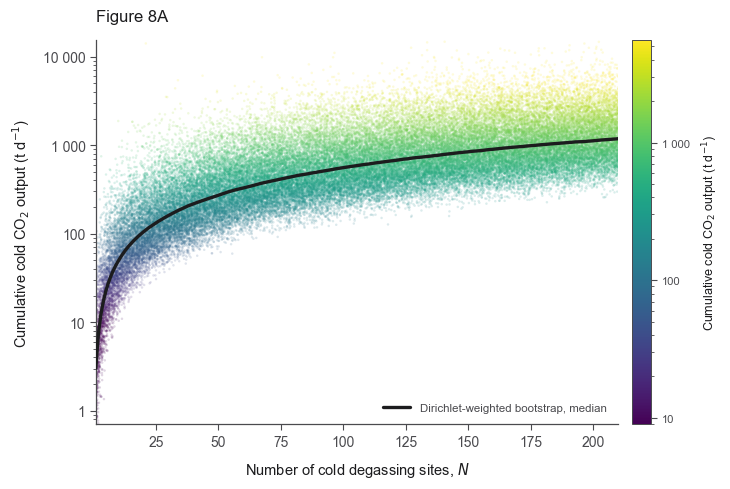


Rendering Figure S9A: non-parametric bootstrap ...
  Saved: figures/Figure_S9A_nonparametric_bootstrap_local_linear.pdf
  Saved: figures/Figure_S9A_nonparametric_bootstrap_local_linear.svg
  Saved: figures/Figure_S9A_nonparametric_bootstrap_local_linear.png
  Saved: figures/Figure_S9A_nonparametric_bootstrap_local_linear.tiff


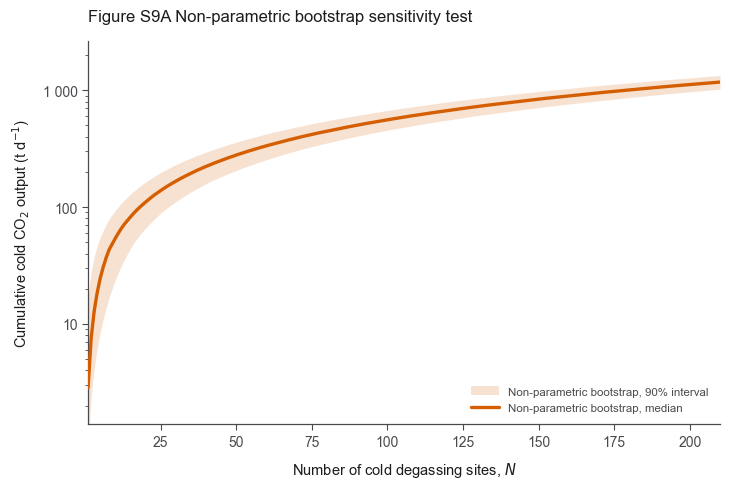


Rendering Figure S9B: fixed-parametric lognormal ...
  Saved: figures/Figure_S9B_fixed_parametric_lognormal_local_linear.pdf
  Saved: figures/Figure_S9B_fixed_parametric_lognormal_local_linear.svg
  Saved: figures/Figure_S9B_fixed_parametric_lognormal_local_linear.png
  Saved: figures/Figure_S9B_fixed_parametric_lognormal_local_linear.tiff


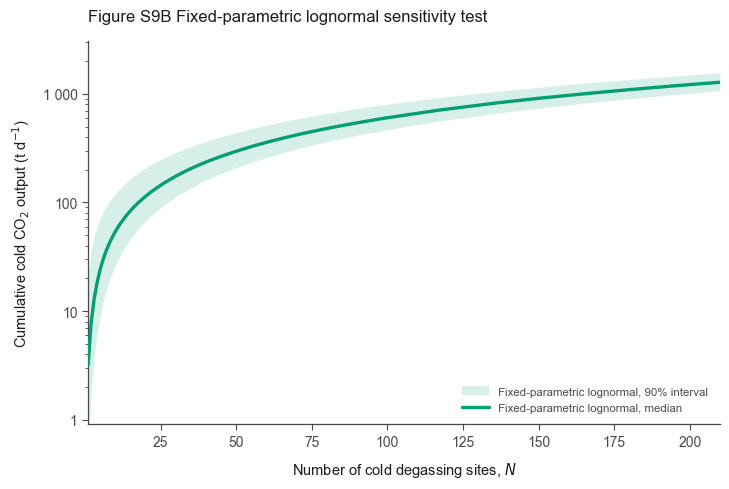


Rendering Figure S9C: all-sites cloud and leave-one-out sensitivity ...

Figure S9C: all-sites model plus leave-one-out median sensitivity test
  All sites: n = 5, range = 1.00-18.60 t/d

Building all-sites Dirichlet point cloud ...
  Excluding Micciano: n = 4, range = 1.20-18.60 t/d
  Excluding Libbiano: n = 4, range = 1.00-18.60 t/d
  Excluding Palazzo al Piano: n = 4, range = 1.00-18.60 t/d
  Excluding Montemiccioli: n = 4, range = 1.00-4.04 t/d
  Excluding Occhibolleri: n = 4, range = 1.00-18.60 t/d
  Saved: figures/Figure_S9C_all_sites_cloud_envelope_with_jackknife_medians.pdf
  Saved: figures/Figure_S9C_all_sites_cloud_envelope_with_jackknife_medians.svg
  Saved: figures/Figure_S9C_all_sites_cloud_envelope_with_jackknife_medians.png
  Saved: figures/Figure_S9C_all_sites_cloud_envelope_with_jackknife_medians.tiff


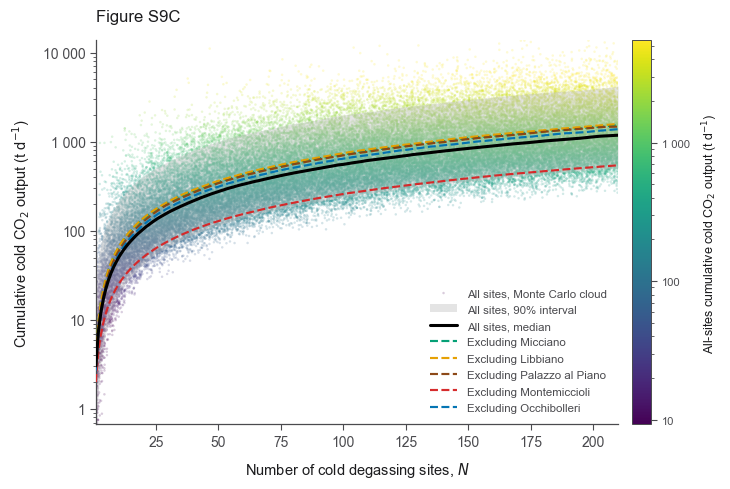


Figure S9C statistics
Unsmoothed Monte Carlo statistics

N = 30
  All sites: median = 162.2 t/d, 90% interval = 66.7-598.4 t/d
  Excluding Micciano         median =   208.5 t/d  (inside all-sites 90% interval)
  Excluding Libbiano         median =   211.9 t/d  (inside all-sites 90% interval)
  Excluding Palazzo al Piano median =   199.9 t/d  (inside all-sites 90% interval)
  Excluding Montemiccioli    median =    76.9 t/d  (inside all-sites 90% interval)
  Excluding Occhibolleri     median =   179.1 t/d  (inside all-sites 90% interval)

N = 100
  All sites: median = 555.2 t/d, 90% interval = 237.3-2022.9 t/d
  Excluding Micciano         median =   719.4 t/d  (inside all-sites 90% interval)
  Excluding Libbiano         median =   755.1 t/d  (inside all-sites 90% interval)
  Excluding Palazzo al Piano median =   708.3 t/d  (inside all-sites 90% interval)
  Excluding Montemiccioli    median =   258.8 t/d  (inside all-sites 90% interval)
  Excluding Occhibolleri     median =   664.8 t/d  

In [3]:
""" Monte Carlo upscaling of cold CO2 degassing in the Tuscan sector of the Northern Apennines back-arc.

Author: A. Rielli, National Research Council of Italy

Figures:
    Figure 8A   Dirichlet-weighted bootstrap point cloud and median
    Figure S9A  Non-parametric bootstrap sensitivity testn
    Figure S9B  Fixed-lognormal sensitivity test
    Figure S9C  Leave-one-out Dirichlet-weighted sensitivity test

Data: Site-integrated cold CO2 outputs from Micciano, Montemiccioli,Libbiano and Palazzo al Piano after Taussi et al. (2023), and Occhibolleri from this study.

Notes: Monte Carlo uncertainty is reported as the 5th-95th percentile range. Curves are smoothed in log-space for plotting only. 
       Printed statistics are calculated from the unsmoothed Monte Carlo distributions. Point clouds are horizontally jittered only for visualisation.
"""


from __future__ import annotations

import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib as mpl


# ---------------------------------------------------------------------------
# Configuration
# ---------------------------------------------------------------------------

RNG_SEED = 42
N_ITER = 10000

# Number of Monte Carlo points shown for each N.
# This does not affect medians, percentile curves, or printed statistics.
N_POINTS_SHOWN = 300

# Use 164 for the manuscript inventory.
# Use 210 only for exploratory plots beyond the current inventory.
N_MAX = 210
N_ALL = np.arange(1, N_MAX + 1)

# N values printed in the console summary.
N_TARGETS = [30, 100, 200]

# Horizontal jitter for point clouds only.
JITTER_WIDTH = 0.60

# Point style.
POINT_SIZE = 3.2
POINT_ALPHA = 0.16
POINT_ALPHA_S9C = 0.20
RASTERIZED_POINTS = False

# Smoothing windows for plotting only.
# Must be odd. Lower values reduce smoothing and preserve original shape.
SMOOTH_WINDOW_MAIN = 7
SMOOTH_WINDOW_S9 = 9

# Output settings.
OUTPUT_DIR = "figures"
PNG_DPI = 600


# ---------------------------------------------------------------------------
# Input data in t/d
# ---------------------------------------------------------------------------

COLD_SITES = {
    "Micciano": 1.0,
    "Libbiano": 1.2,
    "Palazzo al Piano": 3.2,
    "Montemiccioli": 18.6,
    "Occhibolleri": 4.04,
}


# ---------------------------------------------------------------------------
# Design system
# ---------------------------------------------------------------------------

INK = "#1C1C1E"
INK_SOFT = "#4A4A4E"
PAPER = "#FFFFFF"

# Figure colours.
C_DIRICHLET = "#1C1C1E"       # black
C_BOOT = "#D55E00"            # orange
C_PAR = "#009E73"             # green

# Colour scale for point clouds.
CMAP = plt.get_cmap("viridis")

# Leave-one-out colours.
LOO_COLOURS = {
    "Micciano": "#009E73",          # green
    "Libbiano": "#E69F00",         # orange
    "Palazzo al Piano": "#8B4513", # brown
    "Montemiccioli": "#D62728",    # red
    "Occhibolleri": "#0072B2",     # blue
}

# Illustrator-safe font stack.
FONT_STACK = ["Arial", "Helvetica", "DejaVu Sans"]


# ---------------------------------------------------------------------------
# Monte Carlo functions
# ---------------------------------------------------------------------------

def fit_lognormal(values: np.ndarray) -> tuple[float, float]:
    """Fit a lognormal distribution in log-space."""
    log_values = np.log(values)
    mu = float(log_values.mean())
    sigma = float(log_values.std(ddof=1))
    return mu, sigma


def sample_totals_parametric(
    mu: float,
    sigma: float,
    N: int,
    n_iter: int,
    rng: np.random.Generator,
) -> np.ndarray:
    """Fixed-parametric lognormal model."""
    draws = rng.lognormal(
        mean=mu,
        sigma=sigma,
        size=(n_iter, N),
    )
    return draws.sum(axis=1)


def sample_totals_dirichlet_weighted(
    cold: np.ndarray,
    N: int,
    n_iter: int,
    rng: np.random.Generator,
) -> np.ndarray:
    """
    Dirichlet-weighted parametric bootstrap.

    For each Monte Carlo realisation:
    1. draw continuous Dirichlet weights over the observed cold-site outputs;
    2. compute weighted lognormal parameters in log-space;
    3. draw N synthetic site outputs from that weighted lognormal;
    4. sum them.
    """
    log_cold = np.log(cold)
    n_sites = cold.size

    weights = rng.dirichlet(
        alpha=np.ones(n_sites),
        size=n_iter,
    )

    mu_iter = (weights * log_cold[None, :]).sum(axis=1)

    diffs = log_cold[None, :] - mu_iter[:, None]
    weighted_var = (weights * diffs**2).sum(axis=1)

    # Effective-sample-size correction, weighted analogue of ddof = 1.
    correction = 1.0 / (1.0 - np.sum(weights**2, axis=1))
    sigma_iter = np.sqrt(weighted_var * correction)

    draws = rng.lognormal(
        mean=mu_iter[:, None],
        sigma=sigma_iter[:, None],
        size=(n_iter, N),
    )

    return draws.sum(axis=1)


def sample_totals_bootstrap(
    cold: np.ndarray,
    N: int,
    n_iter: int,
    rng: np.random.Generator,
) -> np.ndarray:
    """Non-parametric bootstrap by direct resampling with replacement."""
    draws = rng.choice(
        cold,
        size=(n_iter, N),
        replace=True,
    )
    return draws.sum(axis=1)


def get_totals(
    scheme: str,
    mu: float,
    sigma: float,
    cold: np.ndarray,
    N: int,
    n_iter: int,
    rng: np.random.Generator,
) -> np.ndarray:
    """Dispatch Monte Carlo sampling scheme."""
    if scheme == "dirichlet":
        return sample_totals_dirichlet_weighted(
            cold=cold,
            N=N,
            n_iter=n_iter,
            rng=rng,
        )

    if scheme == "bootstrap":
        return sample_totals_bootstrap(
            cold=cold,
            N=N,
            n_iter=n_iter,
            rng=rng,
        )

    if scheme == "parametric":
        return sample_totals_parametric(
            mu=mu,
            sigma=sigma,
            N=N,
            n_iter=n_iter,
            rng=rng,
        )

    raise ValueError(f"Unknown scheme: {scheme}")


def build_cloud(
    scheme: str,
    mu: float,
    sigma: float,
    cold: np.ndarray,
    n_iter: int,
    n_shown: int,
    rng: np.random.Generator,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Build a scatter cloud for every integer N.

    Only horizontal jitter is applied for visualisation.
    Simulated CO2 totals are not modified.
    """
    xs = []
    ys = []

    for N in N_ALL:
        totals = get_totals(
            scheme=scheme,
            mu=mu,
            sigma=sigma,
            cold=cold,
            N=int(N),
            n_iter=n_iter,
            rng=rng,
        )

        idx = rng.choice(
            n_iter,
            size=min(n_shown, n_iter),
            replace=False,
        )

        x_values = N + rng.uniform(
            low=-JITTER_WIDTH,
            high=JITTER_WIDTH,
            size=len(idx),
        )

        y_values = totals[idx].astype(np.float32)

        xs.append(x_values)
        ys.append(y_values)

    return np.concatenate(xs), np.concatenate(ys)


def build_summary_curves(
    scheme: str,
    mu: float,
    sigma: float,
    cold: np.ndarray,
    n_iter: int,
    rng: np.random.Generator,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Build p5, median, and p95 curves for every integer N."""
    p5 = np.empty(N_MAX)
    p50 = np.empty(N_MAX)
    p95 = np.empty(N_MAX)

    for N in N_ALL:
        totals = get_totals(
            scheme=scheme,
            mu=mu,
            sigma=sigma,
            cold=cold,
            N=int(N),
            n_iter=n_iter,
            rng=rng,
        )

        p5[N - 1], p50[N - 1], p95[N - 1] = np.percentile(
            totals,
            [5, 50, 95],
        )

    return p5, p50, p95


# ---------------------------------------------------------------------------
# Smoothing functions for plotting only
# ---------------------------------------------------------------------------

def smooth_curve_logspace(
    values: np.ndarray,
    window: int = 9,
) -> np.ndarray:
    """
    Smooth a positive 1D curve in log-space for plotting only using a moving
    local-linear regression.

    This avoids padding artefacts and removes artificial steps near N = 1.
    The original Monte Carlo statistics are not modified.
    """
    values = np.asarray(values, dtype=float)

    if np.any(values <= 0):
        raise ValueError("All values must be positive for log-space smoothing.")

    if window <= 1:
        return values.copy()

    if window % 2 == 0:
        window += 1

    half_window = window // 2

    x = np.log(N_ALL.astype(float))
    y = np.log(values)

    y_smooth = np.empty_like(y)

    for i in range(len(y)):
        i0 = max(0, i - half_window)
        i1 = min(len(y), i + half_window + 1)

        x_local = x[i0:i1]
        y_local = y[i0:i1]

        if len(x_local) >= 2:
            coeff = np.polyfit(x_local, y_local, deg=1)
            y_smooth[i] = np.polyval(coeff, x[i])
        else:
            y_smooth[i] = y[i]

    return np.exp(y_smooth)


def smooth_interval_logspace(
    p5: np.ndarray,
    med: np.ndarray,
    p95: np.ndarray,
    window: int = 9,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Smooth p5, median, and p95 in log-space for plotting only, preserving
    percentile order.

    The original Monte Carlo statistics are not modified.
    """
    p5_s = smooth_curve_logspace(p5, window=window)
    med_s = smooth_curve_logspace(med, window=window)
    p95_s = smooth_curve_logspace(p95, window=window)

    p5_s = np.minimum(p5_s, med_s)
    p95_s = np.maximum(p95_s, med_s)

    return p5_s, med_s, p95_s


# ---------------------------------------------------------------------------
# Plotting utilities
# ---------------------------------------------------------------------------

def full_number_formatter(value: float, _: int | None = None) -> str:
    """Format axis labels as full numbers without k abbreviation."""
    return f"{value:,.0f}".replace(",", " ")


def set_plot_style() -> None:
    """Set clean white-background Matplotlib style."""
    plt.rcParams.update({
        "font.family": "sans-serif",
        "font.sans-serif": FONT_STACK,
        "font.size": 10,
        "text.color": INK,
        "axes.edgecolor": INK_SOFT,
        "axes.labelcolor": INK,
        "axes.linewidth": 0.9,
        "axes.facecolor": PAPER,
        "figure.facecolor": PAPER,
        "savefig.facecolor": PAPER,
        "xtick.color": INK_SOFT,
        "ytick.color": INK_SOFT,
        "xtick.direction": "out",
        "ytick.direction": "out",
        "xtick.major.size": 4,
        "ytick.major.size": 4,
        "ytick.minor.size": 2.2,
        "axes.axisbelow": True,

        # Keep text editable in Illustrator.
        "svg.fonttype": "none",
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    })


def save_figure(fig: plt.Figure, filename_base: str) -> None:
    """
    Save figure in vector and raster formats.

    EPS is omitted because PostScript does not support transparency properly.
    """
    os.makedirs(OUTPUT_DIR, exist_ok=True)

    pdf_path = os.path.join(OUTPUT_DIR, f"{filename_base}.pdf")
    svg_path = os.path.join(OUTPUT_DIR, f"{filename_base}.svg")
    png_path = os.path.join(OUTPUT_DIR, f"{filename_base}.png")
    tiff_path = os.path.join(OUTPUT_DIR, f"{filename_base}.tiff")

    fig.savefig(pdf_path, bbox_inches="tight")
    fig.savefig(svg_path, bbox_inches="tight")
    fig.savefig(png_path, dpi=PNG_DPI, bbox_inches="tight")
    fig.savefig(tiff_path, dpi=PNG_DPI, bbox_inches="tight")

    print(f"  Saved: {pdf_path}")
    print(f"  Saved: {svg_path}")
    print(f"  Saved: {png_path}")
    print(f"  Saved: {tiff_path}")


def format_axes(ax: plt.Axes, title: str) -> None:
    """Format axes."""
    ax.set_yscale("log")
    ax.set_xlim(1, N_MAX)

    ax.set_xlabel(
        "Number of cold degassing sites, $N$",
        fontsize=10.5,
        labelpad=8,
    )

    ax.set_ylabel(
        "Cumulative cold CO$_2$ output (t d$^{-1}$)",
        fontsize=10.5,
        labelpad=8,
    )

    ax.yaxis.set_major_locator(mticker.LogLocator(base=10))
    ax.yaxis.set_minor_locator(
        mticker.LogLocator(
            base=10,
            subs=np.arange(2, 10) * 0.1,
        )
    )

    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(full_number_formatter)
    )

    ax.grid(False)

    for spine_name in ("top", "right"):
        ax.spines[spine_name].set_visible(False)

    for spine_name in ("left", "bottom"):
        ax.spines[spine_name].set_color(INK_SOFT)
        ax.spines[spine_name].set_linewidth(0.9)

    ax.set_title(
        title,
        fontsize=12,
        fontweight="medium",
        color=INK,
        pad=14,
        loc="left",
    )


def clean_legend(ax: plt.Axes, loc: str = "lower right") -> None:
    """Compact legend with opaque white background."""
    leg = ax.legend(
        loc=loc,
        frameon=True,
        fontsize=8.3,
        handlelength=2.4,
        labelspacing=0.55,
        borderaxespad=0.6,
        framealpha=1.0,
        facecolor=PAPER,
        edgecolor="none",
    )

    for text in leg.get_texts():
        text.set_color(INK_SOFT)


def add_log_colourbar(
    fig: plt.Figure,
    ax: plt.Axes,
    cloud_norm: mpl.colors.LogNorm,
    label: str,
) -> None:
    """Add formatted log colourbar."""
    cbar_mappable = mpl.cm.ScalarMappable(
        norm=cloud_norm,
        cmap=CMAP,
    )
    cbar_mappable.set_array([])

    cbar = fig.colorbar(
        cbar_mappable,
        ax=ax,
        pad=0.025,
        fraction=0.045,
    )

    cbar.set_label(
        label,
        fontsize=9,
        color=INK,
        labelpad=8,
    )

    cbar.ax.tick_params(
        labelsize=8,
        colors=INK_SOFT,
    )

    cbar.ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(full_number_formatter)
    )

    cbar.outline.set_edgecolor(INK_SOFT)
    cbar.outline.set_linewidth(0.7)


# ---------------------------------------------------------------------------
# Console output
# ---------------------------------------------------------------------------

def print_selected_n_statistics(
    mu: float,
    sigma: float,
    cold: np.ndarray,
    n_iter: int,
) -> None:
    """Print detailed output statistics at selected N values for all schemes."""
    rng_stats = np.random.default_rng(RNG_SEED + 999)

    print("\nOutput statistics at selected N values")
    print("Unsmoothed Monte Carlo statistics; 90% interval = 5th-95th percentile")

    for n_target in N_TARGETS:
        if n_target > N_MAX:
            continue

        print(f"\nOutput statistics at N = {n_target}")

        for name, scheme in (
            ("Dirichlet-weighted bootstrap", "dirichlet"),
            ("Non-parametric bootstrap", "bootstrap"),
            ("Fixed-parametric lognormal", "parametric"),
        ):
            totals = get_totals(
                scheme=scheme,
                mu=mu,
                sigma=sigma,
                cold=cold,
                N=n_target,
                n_iter=n_iter,
                rng=rng_stats,
            )

            p5, p50, p95, p99 = np.percentile(
                totals,
                [5, 50, 95, 99],
            )

            print(f"\n  {name}")
            print(f"    Median output:      {p50:.1f} t/d")
            print(f"    90% interval:       {p5:.1f}-{p95:.1f} t/d")
            print(f"    95th percentile:    {p95:.1f} t/d")
            print(f"    99th percentile:    {p99:.1f} t/d")


# ---------------------------------------------------------------------------
# Figure 8A
# ---------------------------------------------------------------------------

def make_figure_8a_dirichlet_cloud(
    xy_dirichlet: tuple[np.ndarray, np.ndarray],
    med_dirichlet: np.ndarray,
    save: bool = False,
) -> None:
    """
    Figure 8A:
    Dirichlet-weighted parametric bootstrap point cloud and median.
    """
    set_plot_style()

    fig, ax = plt.subplots(figsize=(7.4, 5.0))

    x_cloud, y_cloud = xy_dirichlet

    cloud_norm = mpl.colors.LogNorm(
        vmin=max(0.1, np.percentile(y_cloud, 1)),
        vmax=np.percentile(y_cloud, 99.5),
    )

    ax.scatter(
        x_cloud,
        y_cloud,
        s=POINT_SIZE,
        c=y_cloud,
        cmap=CMAP,
        norm=cloud_norm,
        alpha=POINT_ALPHA,
        linewidths=0,
        rasterized=RASTERIZED_POINTS,
        zorder=2,
    )

    med_plot = smooth_curve_logspace(
        med_dirichlet,
        window=SMOOTH_WINDOW_MAIN,
    )

    ax.plot(
        N_ALL,
        med_plot,
        color=C_DIRICHLET,
        lw=2.4,
        zorder=5,
        label="Dirichlet-weighted bootstrap, median",
        solid_capstyle="round",
    )

    all_y = np.concatenate([y_cloud, med_plot])

    y_lo = max(0.5, np.percentile(all_y, 0.05))
    y_hi = np.percentile(all_y, 99.85) * 2.0
    ax.set_ylim(y_lo, y_hi)

    format_axes(ax, title="Figure 8A")

    add_log_colourbar(
        fig=fig,
        ax=ax,
        cloud_norm=cloud_norm,
        label="Cumulative cold CO$_2$ output (t d$^{-1}$)",
    )

    clean_legend(ax)

    fig.tight_layout()

    if save:
        save_figure(
            fig,
            "Figure_8A_dirichlet_weighted_cloud_viridis_local_linear",
        )

    plt.show()


# ---------------------------------------------------------------------------
# Figure S9A
# ---------------------------------------------------------------------------

def make_figure_s9a_nonparametric_bootstrap(
    p5_boot: np.ndarray,
    med_boot: np.ndarray,
    p95_boot: np.ndarray,
    save: bool = False,
) -> None:
    """
    Figure S9A:
    Non-parametric bootstrap 90% interval and median curve.
    """
    set_plot_style()

    p5_s, med_s, p95_s = smooth_interval_logspace(
        p5_boot,
        med_boot,
        p95_boot,
        window=SMOOTH_WINDOW_S9,
    )

    fig, ax = plt.subplots(figsize=(7.4, 5.0))

    ax.fill_between(
        N_ALL,
        p5_s,
        p95_s,
        color=C_BOOT,
        alpha=0.18,
        linewidth=0,
        zorder=1,
        label="Non-parametric bootstrap, 90% interval",
    )

    ax.plot(
        N_ALL,
        med_s,
        color=C_BOOT,
        lw=2.4,
        zorder=5,
        label="Non-parametric bootstrap, median",
        solid_capstyle="round",
    )

    all_y = np.concatenate([p5_s, med_s, p95_s])

    y_lo = max(0.5, np.percentile(all_y, 0.05))
    y_hi = np.percentile(all_y, 99.85) * 2.0
    ax.set_ylim(y_lo, y_hi)

    format_axes(
        ax,
        title="Figure S9A Non-parametric bootstrap sensitivity test",
    )

    clean_legend(ax)

    fig.tight_layout()

    if save:
        save_figure(
            fig,
            "Figure_S9A_nonparametric_bootstrap_local_linear",
        )

    plt.show()


# ---------------------------------------------------------------------------
# Figure S9B
# ---------------------------------------------------------------------------

def make_figure_s9b_fixed_lognormal(
    p5_par: np.ndarray,
    med_par: np.ndarray,
    p95_par: np.ndarray,
    save: bool = False,
) -> None:
    """
    Figure S9B:
    Fixed-parametric lognormal 90% interval and median curve.
    """
    set_plot_style()

    p5_s, med_s, p95_s = smooth_interval_logspace(
        p5_par,
        med_par,
        p95_par,
        window=SMOOTH_WINDOW_S9,
    )

    fig, ax = plt.subplots(figsize=(7.4, 5.0))

    ax.fill_between(
        N_ALL,
        p5_s,
        p95_s,
        color=C_PAR,
        alpha=0.16,
        linewidth=0,
        zorder=1,
        label="Fixed-parametric lognormal, 90% interval",
    )

    ax.plot(
        N_ALL,
        med_s,
        color=C_PAR,
        lw=2.4,
        zorder=5,
        label="Fixed-parametric lognormal, median",
        solid_capstyle="round",
    )

    all_y = np.concatenate([p5_s, med_s, p95_s])

    y_lo = max(0.5, np.percentile(all_y, 0.05))
    y_hi = np.percentile(all_y, 99.85) * 2.0
    ax.set_ylim(y_lo, y_hi)

    format_axes(
        ax,
        title="Figure S9B Fixed-parametric lognormal sensitivity test",
    )

    clean_legend(ax)

    fig.tight_layout()

    if save:
        save_figure(
            fig,
            "Figure_S9B_fixed_parametric_lognormal_local_linear",
        )

    plt.show()


# ---------------------------------------------------------------------------
# Figure S9C
# ---------------------------------------------------------------------------

def make_figure_s9c_full_cloud_envelope_with_jackknife_medians(
    save: bool = False,
) -> dict[str, object]:
    """
    Figure S9C:
    All-sites Dirichlet-weighted model point cloud, 90% envelope, median,
    and leave-one-out median curves.

    The leave-one-out curves test whether the regional upscaling is controlled
    by any single quantified cold-degassing locality.
    """
    set_plot_style()

    rng_loo = np.random.default_rng(RNG_SEED + 2029)

    cold_dict = COLD_SITES.copy()
    cold_all = np.array(list(cold_dict.values()), dtype=float)

    mu_all, sigma_all = fit_lognormal(cold_all)

    print("\nFigure S9C: all-sites model plus leave-one-out median sensitivity test")
    print(
        f"  All sites: n = {cold_all.size}, "
        f"range = {cold_all.min():.2f}-{cold_all.max():.2f} t/d"
    )

    # -----------------------------------------------------------------------
    # All-sites model: point cloud, 90% envelope, and median
    # -----------------------------------------------------------------------

    print("\nBuilding all-sites Dirichlet point cloud ...")

    xy_all = build_cloud(
        scheme="dirichlet",
        mu=mu_all,
        sigma=sigma_all,
        cold=cold_all,
        n_iter=N_ITER,
        n_shown=N_POINTS_SHOWN,
        rng=rng_loo,
    )

    p5_all, med_all, p95_all = build_summary_curves(
        scheme="dirichlet",
        mu=mu_all,
        sigma=sigma_all,
        cold=cold_all,
        n_iter=N_ITER,
        rng=rng_loo,
    )

    p5_all_s, med_all_s, p95_all_s = smooth_interval_logspace(
        p5_all,
        med_all,
        p95_all,
        window=SMOOTH_WINDOW_S9,
    )

    # -----------------------------------------------------------------------
    # Leave-one-out medians
    # -----------------------------------------------------------------------

    loo_results = {}

    for excluded_site in cold_dict.keys():

        cold_subset = np.array(
            [
                value
                for site, value in cold_dict.items()
                if site != excluded_site
            ],
            dtype=float,
        )

        mu_subset, sigma_subset = fit_lognormal(cold_subset)

        p5_loo, med_loo, p95_loo = build_summary_curves(
            scheme="dirichlet",
            mu=mu_subset,
            sigma=sigma_subset,
            cold=cold_subset,
            n_iter=N_ITER,
            rng=rng_loo,
        )

        med_loo_s = smooth_curve_logspace(
            med_loo,
            window=SMOOTH_WINDOW_S9,
        )

        loo_results[excluded_site] = {
            "cold_subset": cold_subset,
            "p5": p5_loo,
            "med": med_loo,
            "p95": p95_loo,
            "med_smooth": med_loo_s,
            "colour": LOO_COLOURS[excluded_site],
        }

        print(
            f"  Excluding {excluded_site}: "
            f"n = {cold_subset.size}, "
            f"range = {cold_subset.min():.2f}-{cold_subset.max():.2f} t/d"
        )

    # -----------------------------------------------------------------------
    # Plot
    # -----------------------------------------------------------------------

    fig, ax = plt.subplots(figsize=(7.4, 5.0))

    x_all, y_all = xy_all

    cloud_norm = mpl.colors.LogNorm(
        vmin=max(0.1, np.percentile(y_all, 1)),
        vmax=np.percentile(y_all, 99.5),
    )

    # All-sites Monte Carlo point cloud.
    ax.scatter(
        x_all,
        y_all,
        s=POINT_SIZE,
        c=y_all,
        cmap=CMAP,
        norm=cloud_norm,
        alpha=POINT_ALPHA_S9C,
        linewidths=0,
        rasterized=RASTERIZED_POINTS,
        zorder=1,
        label="All sites, Monte Carlo cloud",
    )

    # All-sites 90% envelope.
    ax.fill_between(
        N_ALL,
        p5_all_s,
        p95_all_s,
        color="0.75",
        alpha=0.42,
        linewidth=0,
        zorder=2,
        label="All sites, 90% interval",
    )

    # All-sites median.
    ax.plot(
        N_ALL,
        med_all_s,
        color="black",
        lw=2.2,
        zorder=8,
        label="All sites, median",
        solid_capstyle="round",
    )

    # Leave-one-out medians.
    for excluded_site, res in loo_results.items():
        ax.plot(
            N_ALL,
            res["med_smooth"],
            color=res["colour"],
            lw=1.55,
            ls="--",
            alpha=0.98,
            zorder=7,
            label=f"Excluding {excluded_site}",
            solid_capstyle="round",
        )

    all_y = [y_all, p5_all_s, med_all_s, p95_all_s]
    all_y.extend([res["med_smooth"] for res in loo_results.values()])
    all_y = np.concatenate(all_y)

    y_lo = max(0.5, np.percentile(all_y, 0.05))
    y_hi = np.percentile(all_y, 99.85) * 1.8
    ax.set_ylim(y_lo, y_hi)

    format_axes(
        ax,
        title="Figure S9C",
    )

    add_log_colourbar(
        fig=fig,
        ax=ax,
        cloud_norm=cloud_norm,
        label="All-sites cumulative cold CO$_2$ output (t d$^{-1}$)",
    )

    clean_legend(ax, loc="lower right")

    fig.tight_layout()

    if save:
        save_figure(
            fig,
            "Figure_S9C_all_sites_cloud_envelope_with_jackknife_medians",
        )

    plt.show()

    # -----------------------------------------------------------------------
    # Print selected statistics
    # -----------------------------------------------------------------------

    print("\nFigure S9C statistics")
    print("Unsmoothed Monte Carlo statistics")

    for n_target in N_TARGETS:
        if n_target > N_MAX:
            continue

        idx = n_target - 1

        print(f"\nN = {n_target}")

        print(
            "  All sites: "
            f"median = {med_all[idx]:.1f} t/d, "
            f"90% interval = {p5_all[idx]:.1f}-{p95_all[idx]:.1f} t/d"
        )

        for excluded_site, res in loo_results.items():
            med_loo = res["med"][idx]

            inside_full_interval = (
                p5_all[idx] <= med_loo <= p95_all[idx]
            )

            status = (
                "inside all-sites 90% interval"
                if inside_full_interval
                else "outside all-sites 90% interval"
            )

            print(
                f"  Excluding {excluded_site:<16} "
                f"median = {med_loo:7.1f} t/d  "
                f"({status})"
            )

    return {
        "all_sites": {
            "xy": xy_all,
            "p5": p5_all,
            "med": med_all,
            "p95": p95_all,
            "p5_smooth": p5_all_s,
            "med_smooth": med_all_s,
            "p95_smooth": p95_all_s,
        },
        "leave_one_out": loo_results,
    }


# ---------------------------------------------------------------------------
# Main
# ---------------------------------------------------------------------------

def main() -> dict[str, object]:
    rng = np.random.default_rng(RNG_SEED)

    cold = np.array(list(COLD_SITES.values()), dtype=float)
    mu, sigma = fit_lognormal(cold)

    print("\nInput data")
    print(f"  Quantified cold sites n = {cold.size}")
    print(f"  Sites: {', '.join(COLD_SITES.keys())}")
    print(f"  Cold-site outputs = {cold.min():.2f}-{cold.max():.2f} t/d")
    print(f"  Arithmetic mean = {cold.mean():.2f} t/d")
    print(f"  Geometric mean = {np.exp(mu):.2f} t/d")
    print(f"  Lognormal fit: mu = {mu:.3f}, sigma = {sigma:.3f} [log-space]")

    print(
        f"\nRunning Monte Carlo: "
        f"{N_MAX} N values x {N_ITER} iterations x 3 schemes"
    )

    # -----------------------------------------------------------------------
    # Figure 8A
    # -----------------------------------------------------------------------

    print("\nBuilding Figure 8A point cloud ...")

    xy_dirichlet = build_cloud(
        scheme="dirichlet",
        mu=mu,
        sigma=sigma,
        cold=cold,
        n_iter=N_ITER,
        n_shown=N_POINTS_SHOWN,
        rng=rng,
    )

    print("Building summary curves ...")

    p5_dirichlet, med_dirichlet, p95_dirichlet = build_summary_curves(
        scheme="dirichlet",
        mu=mu,
        sigma=sigma,
        cold=cold,
        n_iter=N_ITER,
        rng=rng,
    )

    p5_boot, med_boot, p95_boot = build_summary_curves(
        scheme="bootstrap",
        mu=mu,
        sigma=sigma,
        cold=cold,
        n_iter=N_ITER,
        rng=rng,
    )

    p5_par, med_par, p95_par = build_summary_curves(
        scheme="parametric",
        mu=mu,
        sigma=sigma,
        cold=cold,
        n_iter=N_ITER,
        rng=rng,
    )

    print_selected_n_statistics(
        mu=mu,
        sigma=sigma,
        cold=cold,
        n_iter=N_ITER,
    )

    print("\nRendering Figure 8A: Dirichlet-weighted bootstrap ...")

    make_figure_8a_dirichlet_cloud(
        xy_dirichlet=xy_dirichlet,
        med_dirichlet=med_dirichlet,
        save=True,
    )

    # -----------------------------------------------------------------------
    # Figure S9A
    # -----------------------------------------------------------------------

    print("\nRendering Figure S9A: non-parametric bootstrap ...")

    make_figure_s9a_nonparametric_bootstrap(
        p5_boot=p5_boot,
        med_boot=med_boot,
        p95_boot=p95_boot,
        save=True,
    )

    # -----------------------------------------------------------------------
    # Figure S9B
    # -----------------------------------------------------------------------

    print("\nRendering Figure S9B: fixed-parametric lognormal ...")

    make_figure_s9b_fixed_lognormal(
        p5_par=p5_par,
        med_par=med_par,
        p95_par=p95_par,
        save=True,
    )

    # -----------------------------------------------------------------------
    # Figure S9C
    # -----------------------------------------------------------------------

    print("\nRendering Figure S9C: all-sites cloud and leave-one-out sensitivity ...")

    s9c_results = make_figure_s9c_full_cloud_envelope_with_jackknife_medians(
        save=True,
    )

    return {
        "cold": cold,
        "mu": mu,
        "sigma": sigma,

        "xy_dirichlet": xy_dirichlet,

        "p5_dirichlet": p5_dirichlet,
        "med_dirichlet": med_dirichlet,
        "p95_dirichlet": p95_dirichlet,

        "p5_boot": p5_boot,
        "med_boot": med_boot,
        "p95_boot": p95_boot,

        "p5_par": p5_par,
        "med_par": med_par,
        "p95_par": p95_par,

        "s9c_results": s9c_results,
    }


if __name__ == "__main__":
    results = main()

In [4]:
import sys

print(sys.version)

3.11.15 | packaged by conda-forge | (main, Mar  5 2026, 16:59:26) [Clang 19.1.7 ]
